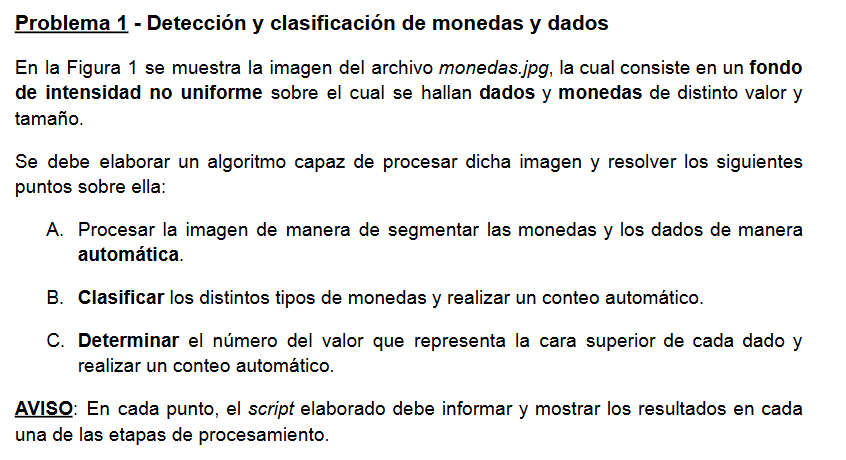

In [88]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

# probando con otro umbralado

tecnica top-hat (PI_U6_Morfologico_pt_grises.py)

In [89]:
img_color = cv2.imread('img/monedas.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

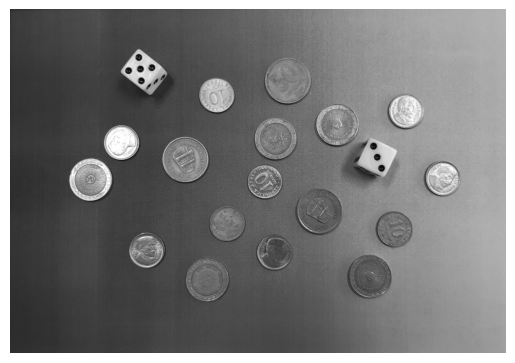

In [90]:
gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)

plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

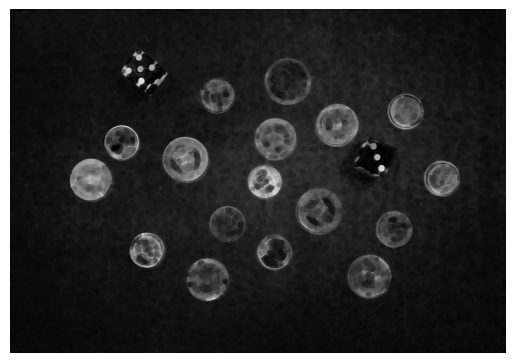

In [91]:
# Operaciones Top-Hat y Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

# Top-Hat (objetos brillantes)
tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

# Black-Hat (Objetos oscuros)
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

# combinar mascaras
mask = cv2.add(tophat, blackhat)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

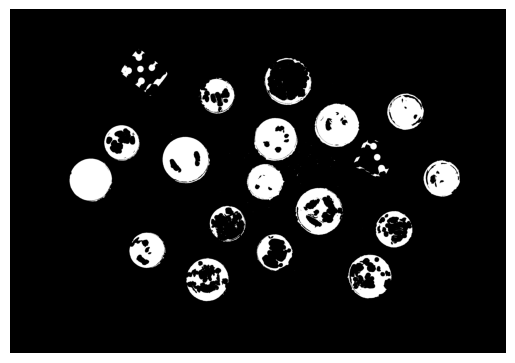

In [92]:
#umbralado
ret, mask_thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_thresh, cmap='gray')
plt.axis('off')
plt.show()

In [97]:
# componenes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
) 

output_image = img_color.copy()
objetos_reales = 0

for i in range(1, num_labels): # Empezamos en 1 para saltar el fondo
    area = stats[i, cv2.CC_STAT_AREA]
    
    # filtramos objetos muy pequeños (ruido)
    if area < 8000: 
        continue
    
    objetos_reales += 1
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (cX, cY) = centroids[i] 
    cv2.putText(output_image, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {objetos_reales} objetos.")

Se encontraron 17 objetos.


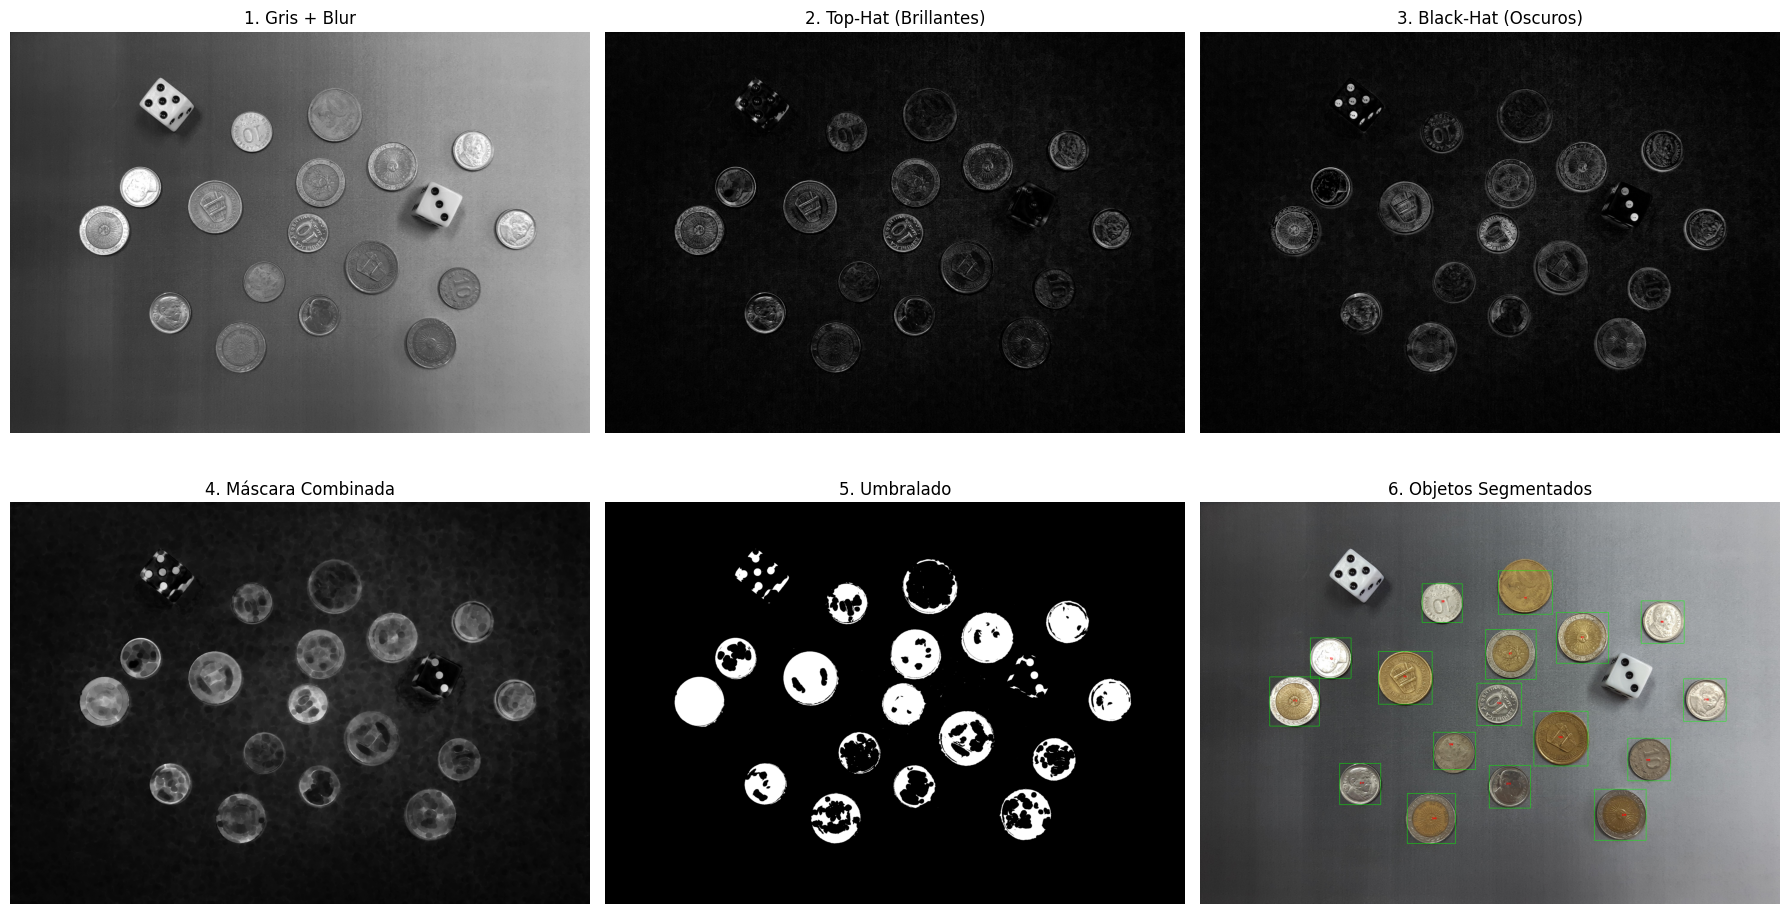

In [99]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray_blur, cmap='gray')
plt.title('1. Gris + Blur')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tophat, cmap='gray')
plt.title('2. Top-Hat (Brillantes)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blackhat, cmap='gray')
plt.title('3. Black-Hat (Oscuros)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Máscara Combinada')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_thresh, cmap='gray')
plt.title('5. Umbralado')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('6. Objetos Segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()